# SplisosmNP vs SplisosmFFT (Visium FFPE, probe)

The relative small spot size (n_max = 4992) and regular hexagonal lattice of **standard 10x Visium data** make it an ideal test case for comparing the two SPLISOSM implementations: `SplisosmNP` (full-rank) and `SplisosmFFT`. 

| Class | Input | Spatial kernel |
|-------|-------|---------------|
| `SplisosmNP` | `AnnData` with `obsm["spatial"]` | Sparse CAR (k-NN graph) |
| `SplisosmFFT` | `SpatialData` with rasterized grid (hexagonal to square) | Block-circulant CAR (periodic) |

In this tutorial, we run spatial variability tests using both methods on a [Visium v2 CytAssist FFPE dataset of adult mouse brain](https://www.10xgenomics.com/datasets/mouse-brain-coronal-section-1-ffpe-2-standard) with probe-level quantification ([Visium Mouse Transcriptome Probe Set v1.0](https://www.10xgenomics.com/support/cytassist-spatial-gene-expression/documentation/steps/probe-sets/visium-mouse-transcriptome-probe-set-v1-0)), and verify that they yield concordant results.

Estimated runtime: 1 min.


## Imports

In [1]:
from __future__ import annotations

from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import spearmanr

from splisosm import SplisosmNP, SplisosmFFT
from splisosm.io import load_visium_probe

warnings.filterwarnings('ignore', category=FutureWarning)
plt.rcParams['figure.dpi'] = 120

In [2]:
visium_outs = Path("/path/to/visium_ffpe/outs")

In [3]:
visium_outs = Path("/Users/jysumac/Projects/SPLISOSM_paper/data/visium_ffpe_mouse_cbs/outs")

## Load probe-level data from Space Ranger output

After running the Space Ranger (**v4.0**) count pipeline, we use `load_visium_probe` to read the `raw_probe_bc_matrix.h5` file from the output directory.
It optionally returns either an AnnData or a SpatialData. Both preserve probe-level var metadata (`gene_ids`, `probe_ids`, `gene_name`, etc.).

In [4]:
%%time
import warnings
with warnings.catch_warnings():
    warnings.filterwarnings('ignore', category=UserWarning)
    # AnnData mode — for SplisosmNP (default)
    adata = load_visium_probe(visium_outs, return_type='anndata')
    print(adata)

    # SpatialData mode — for SplisosmFFT
    sdata = load_visium_probe(visium_outs, return_type='spatialdata')
    print(sdata)

AnnData object with n_obs × n_vars = 2310 × 21178
    obs: 'filtered_barcodes', 'in_tissue', 'array_row', 'array_col'
    var: 'gene_ids', 'probe_ids', 'feature_types', 'filtered_probes', 'gene_name', 'genome', 'probe_region'
    uns: 'spatial'
    obsm: 'spatial'
    layers: 'counts'


SpatialData object
├── Images
│     ├── 'visium_ffpe_mouse_cbs_hires_image': DataArray[cyx] (3, 2000, 1872)
│     └── 'visium_ffpe_mouse_cbs_lowres_image': DataArray[cyx] (3, 600, 562)
├── Shapes
│     └── 'visium_ffpe_mouse_cbs': GeoDataFrame shape: (2310, 2) (2D shapes)
└── Tables
      └── 'table': AnnData (2310, 21178)
with coordinate systems:
    ▸ 'visium_ffpe_mouse_cbs', with elements:
        visium_ffpe_mouse_cbs_hires_image (Images), visium_ffpe_mouse_cbs_lowres_image (Images), visium_ffpe_mouse_cbs (Shapes)
    ▸ 'visium_ffpe_mouse_cbs_downscaled_hires', with elements:
        visium_ffpe_mouse_cbs_hires_image (Images), visium_ffpe_mouse_cbs (Shapes)
    ▸ 'visium_ffpe_mouse_cbs_downscaled_lowres', with elements:
        visium_ffpe_mouse_cbs_lowres_image (Images), visium_ffpe_mouse_cbs (Shapes)
CPU times: user 1.63 s, sys: 276 ms, total: 1.91 s
Wall time: 2.04 s


In [5]:
adata.var.head(3)

,gene_ids,probe_ids,feature_types,filtered_probes,gene_name,genome,probe_region
Itgb2l|2ef1e7b,DEPRECATED_ENSMUSG00000000157,DEPRECATED_ENSMUSG00000000157|Itgb2l|2ef1e7b,Gene Expression,False,DEPRECATED_ENSMUSG00000000157,mm10,none
Btn1a1|49a22c6,DEPRECATED_ENSMUSG00000000706,DEPRECATED_ENSMUSG00000000706|Btn1a1|49a22c6,Gene Expression,False,DEPRECATED_ENSMUSG00000000706,mm10,none
Timp1|9dd7d08,DEPRECATED_ENSMUSG00000001131,DEPRECATED_ENSMUSG00000001131|Timp1|9dd7d08,Gene Expression,False,DEPRECATED_ENSMUSG00000001131,mm10,none


10x Visium spots are arranged in a hexagonal lattice, with grid indices `array_row` and `array_col` in `adata.obs`, and spatial coordinates of spots centroids in `adata.obsm["spatial"]`.

- `array_row`: the row index of the spot in the hexagonal grid (from 0 to 77)
- `array_col`: the column index of the spot in the hexagonal grid (from 0 to 127), even numbers for even rows and odd numbers for odd rows
- `obsm["spatial"]`: the (x, y) coordinates of the spot (`pxl_row_in_fullres`, `pxl_col_in_fullres`) in the original image coordinate system (in pixels)

See [10x documentation](https://www.10xgenomics.com/support/software/space-ranger/latest/analysis/outputs/spatial-outputs) for more details on the spatial metadata.

In [6]:
print(adata.obs[['array_row', 'array_col']].head(3))
print(adata.obsm['spatial'][:3,:])

                    array_row  array_col
AACACTTGGCAAGGAA-1         47         71
AACAGGATTCATAGTT-1         49         43
AACAGGTTATTGCACC-1         28         86
[[16003.03063455 20105.36253564]
 [21119.36714956 20734.51500256]
 [13254.7453719  14068.95800173]]


In the following sections, we will use `obsm["spatial"]` to build the spatial graph for `SplisosmNP`, and use `(array_row, array_col)` to create a square grid for `SplisosmFFT`.

## Running `SplisosmNP` for spatial variability in probe usage

`SplisosmNP` works directly on AnnData. We use `gene_ids` to group probes by gene. After filtering, only 281 multi-probe genes were kept for spatial variability in probe usage.

In [7]:
%%time
model_np = SplisosmNP()
model_np.setup_data(
    adata, layer='counts', group_iso_by='gene_ids', gene_names='gene_name',
    spatial_key='spatial', min_counts=10, filter_single_iso_genes=True,
)
model_np

CPU times: user 603 ms, sys: 44.1 ms, total: 647 ms
Wall time: 275 ms


=== SplisosmNP
- Number of genes: 281
- Number of spots: 2310
- Number of covariates: 0
- Average isoforms per gene: 2.1
=== Model configurations
- Spatial kernel source: spatial_key='spatial'
- k_neighbors: 4, rho: 0.99
- Standardize spatial covariance: True
=== Test results
- Spatial variability: N/A
- Differential usage: N/A

Since the dataset is small, SV test will by default run in full-rank mode (no approximation) and will be fast.

In [8]:
%%time
# Run SV test to find genes with spatially variable probe usage
model_np.test_spatial_variability(
    method='hsic-ir', 
    null_method='liu', # default
    # null_configs={'n_probes': 60}  # optional tuning for trace accuracy
)
results_np = model_np.get_formatted_test_results('sv', with_gene_summary=True)

SV [hsic-ir]:   0%|          | 0/281 [00:00<?, ?it/s]

SV [hsic-ir]:  64%|██████▍   | 180/281 [00:00<00:00, 1746.05it/s]

SV [hsic-ir]: 100%|██████████| 281/281 [00:00<00:00, 1766.99it/s]

CPU times: user 1.1 s, sys: 361 ms, total: 1.46 s
Wall time: 929 ms


In [9]:
print(f'SVP genes (FDR < 0.01): {(results_np["pvalue_adj"] < 0.01).sum()} / {len(results_np)}')
results_np.sort_values('pvalue_adj').head(5)

SVP genes (FDR < 0.01): 60 / 281


,gene,statistic,pvalue,pvalue_adj,n_isos,perplexity,pct_bin_on,count_avg,count_std,major_ratio_avg
219,Kalrn,0.000483,8.579050e-170,2.410713e-167,2,1.840045,0.957576,12.988312,12.532429,0.701263
66,Gabbr1,0.000233,1.709195e-128,2.401419e-126,2,1.999731,0.991775,17.642424,14.411285,0.508196
132,Map4,0.000320,4.906387e-122,4.595650e-120,2,1.934026,0.988312,9.772294,7.393756,0.628776
51,Oxr1,0.000457,4.228494e-104,2.970517e-102,2,1.988226,0.898268,4.601732,3.779965,0.554280
87,Gnas,0.000014,3.555234e-102,1.998041e-100,5,1.411140,1.000000,48.459307,35.816461,0.917251


Let's visualize the top significant spatially variably processed (SVP) genes.

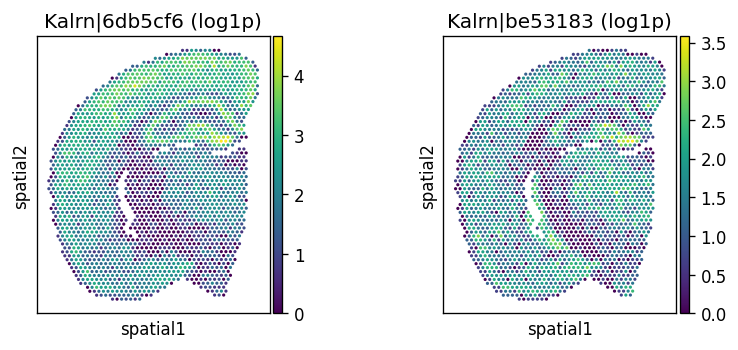

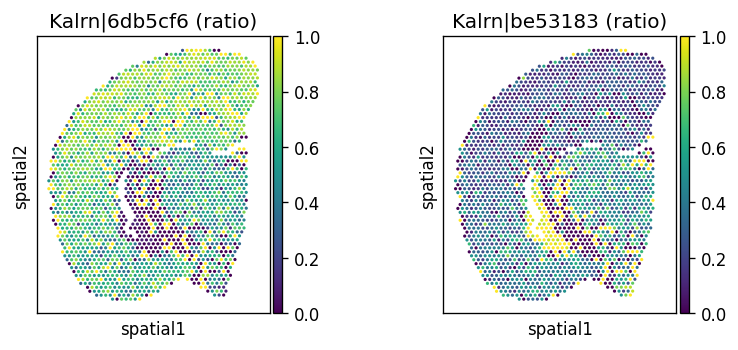

CPU times: user 686 ms, sys: 105 ms, total: 791 ms
Wall time: 805 ms


In [10]:
%%time
import scanpy as sc
from splisosm.utils import add_ratio_layer

# Compute log1p counts
adata.layers['log1p'] = np.log1p(adata.layers['counts'])

# Add observed ratios to the anndata
add_ratio_layer(adata, layer='counts', group_iso_by='gene_ids', ratio_layer_key='ratios_obs')

# Spatially variably processed: Kalrn
_gene = "Kalrn"
_probes = adata.var.query(f'gene_name == @_gene').index.tolist()
_titles_log1p = [f"{name} (log1p)" for name in _probes]
_titles_ratio = [f"{name} (ratio)" for name in _probes]
with plt.rc_context({"figure.figsize": (3, 3)}):
    sc.pl.spatial(
        adata, color=_probes, title=_titles_log1p,
        img_key=None, layer='log1p', ncols = len(_probes)
    )
    sc.pl.spatial(
        adata, color=_probes, title=_titles_ratio,
        img_key=None, layer='ratios_obs', ncols = len(_probes)
    )


## Running `SplisosmFFT` for spatial variability in probe usage

Standard Visium uses a staggered hexagonal grid (col step = 2). When using the `(array_row, array_col)` indices for rasterization in `spatialdata.rasterize_bins`, 
not indexed positions (i.e., odd number indices for even rows and even number indices for odd rows) are automatically filled with zeros (col step = 1).

In [11]:
%%time
from spatialdata import rasterize_bins
# Rasterize Visium spots into a rectangular grid
sdata.tables['table'].X = sdata.tables['table'].X.tocsc()
sdata['rasterized'] = rasterize_bins(
    sdata, 
    bins='visium_ffpe_mouse_cbs',
    table_name='table',
    col_key='array_col', 
    row_key='array_row'
)

CPU times: user 174 ms, sys: 11.2 ms, total: 186 ms
Wall time: 186 ms


In [12]:
_, ny, nx = sdata['rasterized'].shape
n_spots = sdata.tables['table'].shape[0]
print(f'Raster grid: {ny} x {nx} = {ny * nx} cells')
print(f'Observed spots: {n_spots}')
print(f'Occupancy: {n_spots / (ny * nx) * 100:.1f}%')

Raster grid: 64 x 93 = 5952 cells
Observed spots: 2310
Occupancy: 38.8%


The resulting grid look like a checkerboard. 

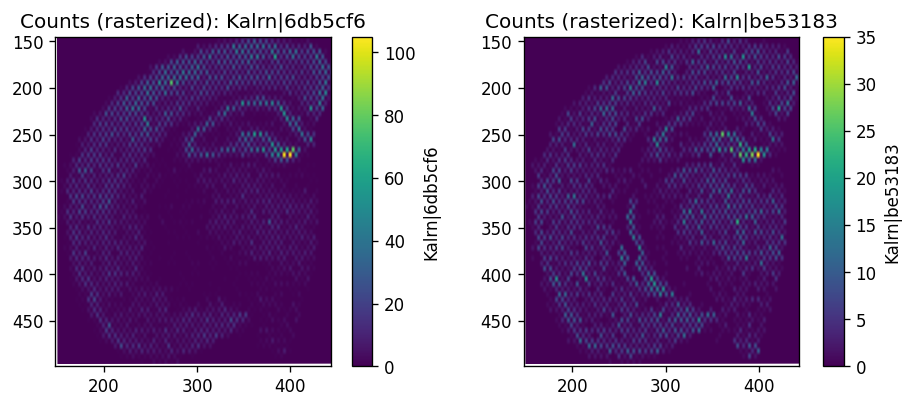

CPU times: user 334 ms, sys: 32.2 ms, total: 367 ms
Wall time: 402 ms


In [13]:

%%time
import spatialdata_plot

# Visualize a selected gene
_gene = 'Kalrn'
_probes = adata.var.query('gene_name == @_gene').index.tolist()
fig, axes = plt.subplots(1, len(_probes), figsize=(4*len(_probes), 4))
for i, probe in enumerate(_probes):
    sdata.pl.render_images(f"rasterized", channel=probe).pl.show(
        coordinate_systems=f"visium_ffpe_mouse_cbs_downscaled_lowres",
        ax = axes[i],
        title=f"Counts (rasterized): {probe}"
    )

plt.subplots_adjust(wspace=0.7)
plt.show()

The empty cells increase the grid size by 2×, change spatial connectivity (the nearest neighbors for all spots are now empty bins) and also the physical scale of rasterized pixels (the new y-axis unit step is $\sqrt{3}$ of the x-axis unit).
To reflect these changes, when running `SplisosmFFT`, we adjust for the following parameters:

- `neighbor_degree` to include the second-nearest neighbors in the hexagonal lattice
- `spacing` to compensate for ny (`array_row`) spacing as compared to nx (`array_col`) spacing ($\frac{1}{\sqrt{3}} \rightarrow 1$) in the rasterized grid. 

In [14]:
%%time
model_fft = SplisosmFFT(
    rho=0.99, 
    neighbor_degree=2, # original nearest neighbors become second nearest due to padding
    spacing=(np.sqrt(3), 1.0),  # x-axis (array_col) is stretched in the rasterized image
)
model_fft.setup_data(
    sdata, bins='visium_ffpe_mouse_cbs', table_name='table',
    col_key='array_col', row_key='array_row', layer='counts',
    group_iso_by='gene_ids', gene_names='gene_name',
    min_counts=10, filter_single_iso_genes=True,
)
model_fft

CPU times: user 2.24 s, sys: 58.4 ms, total: 2.29 s
Wall time: 2.29 s


=== SplisosmFFT
- Number of genes: 281
- Number of spots: 2310
- Number of spots after rasterization: 5952
- Number of covariates: 0
- Average isoforms per gene: 2.1
=== Model configurations
- Neighborhood degree: 2
- Spatial autocorrelation rho: 0.99
=== Test results
- Spatial variability: N/A
- Differential usage: N/A

In [15]:
%%time
model_fft.test_spatial_variability(method='hsic-ir')
results_fft = model_fft.get_formatted_test_results('sv', with_gene_summary=True)

SV [hsic-ir]:   0%|          | 0/281 [00:00<?, ?it/s]

SV [hsic-ir]:  14%|█▍        | 40/281 [00:00<00:00, 258.48it/s]

SV [hsic-ir]:  23%|██▎       | 66/281 [00:00<00:00, 256.26it/s]

SV [hsic-ir]:  33%|███▎      | 92/281 [00:00<00:00, 215.25it/s]

SV [hsic-ir]:  43%|████▎     | 120/281 [00:00<00:00, 192.26it/s]

...

SV [hsic-ir]:  82%|████████▏ | 230/281 [00:01<00:00, 194.12it/s]

SV [hsic-ir]:  89%|████████▉ | 250/281 [00:01<00:00, 192.41it/s]

SV [hsic-ir]: 100%|█████████▉| 280/281 [00:01<00:00, 197.76it/s]

SV [hsic-ir]: 100%|██████████| 281/281 [00:01<00:00, 201.30it/s]

CPU times: user 1.54 s, sys: 234 ms, total: 1.78 s
Wall time: 1.57 s


In [16]:
print(f'SVP genes (FDR < 0.01): {(results_fft["pvalue_adj"] < 0.01).sum()} / {len(results_fft)}')
results_fft.sort_values('pvalue_adj').head(5)

SVP genes (FDR < 0.01): 74 / 281


,gene,statistic,pvalue,pvalue_adj,n_isos,perplexity,pct_bin_on,count_avg,count_std,major_ratio_avg
219,Kalrn,0.000096,4.989955e-198,1.402177e-195,2,1.840045,0.957576,12.988312,12.532429,0.701263
132,Map4,0.000080,6.494533e-190,9.124818e-188,2,1.934026,0.988312,9.772294,7.393756,0.628776
66,Gabbr1,0.000050,9.687196e-162,9.073674e-160,2,1.999731,0.991775,17.642424,14.411285,0.508196
87,Gnas,0.000003,6.290959e-127,4.419399e-125,5,1.411140,1.000000,48.459307,35.816461,0.917251
51,Oxr1,0.000098,5.022497e-126,2.822643e-124,2,1.988226,0.898268,4.601732,3.779965,0.554280


## Comparison: SplisosmNP vs SplisosmFFT

Overall, the two approaches produce highly concordant test statistics and p-values.

In [17]:
r_np = results_np.set_index('gene')
r_fft = results_fft.set_index('gene')
common = r_np.index.intersection(r_fft.index)
df = pd.DataFrame({
    'stat_np': r_np.loc[common, 'statistic'],
    'stat_fft': r_fft.loc[common, 'statistic'],
    'padj_np': r_np.loc[common, 'pvalue_adj'],
    'padj_fft': r_fft.loc[common, 'pvalue_adj'],
})
rho_stat, _ = spearmanr(df['stat_np'], df['stat_fft'])
rho_pval, _ = spearmanr(df['padj_np'], df['padj_fft'])
sig_np = set(df[df['padj_np'] < 0.01].index)
sig_fft = set(df[df['padj_fft'] < 0.01].index)
overlap = sig_np & sig_fft
print(f'Common genes tested:     {len(common)}')
print(f'Spearman rho (stat):     {rho_stat:.4f}')
print(f'Spearman rho (pval-adj):    {rho_pval:.4f}')
print(f'SVP genes — NP:          {len(sig_np)}')
print(f'SVP genes — FFT:         {len(sig_fft)}')
print(f'Overlap:                 {len(overlap)}')

Common genes tested:     281
Spearman rho (stat):     0.9969
Spearman rho (pval-adj):    0.9616
SVP genes — NP:          60
SVP genes — FFT:         74
Overlap:                 59


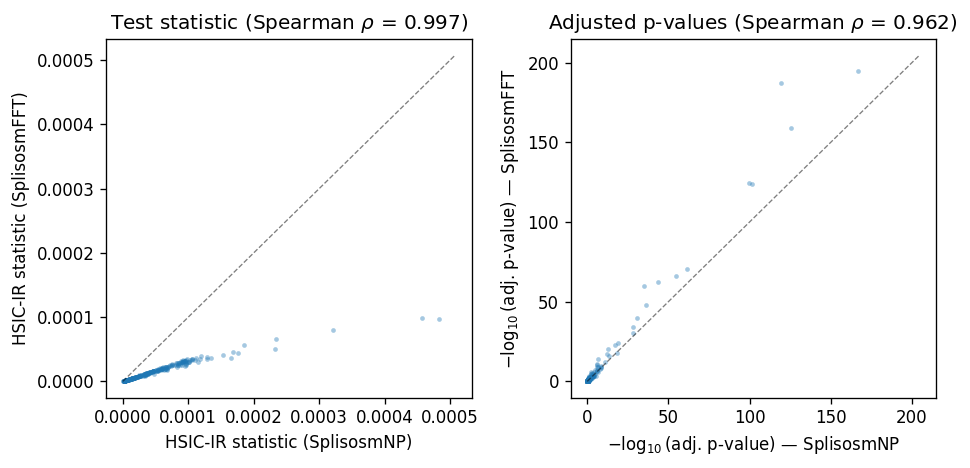

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(8, 4))

# Test statistic
ax = axes[0]
ax.scatter(df['stat_np'], df['stat_fft'], s=8, alpha=0.4, linewidths=0)
lim = max(df['stat_np'].max(), df['stat_fft'].max()) * 1.05
ax.plot([0, lim], [0, lim], 'k--', lw=0.8, alpha=0.5)
ax.set_xlabel('HSIC-IR statistic (SplisosmNP)')
ax.set_ylabel('HSIC-IR statistic (SplisosmFFT)')
ax.set_title(f'Test statistic (Spearman $\\rho$ = {rho_stat:.3f})')

# P-value
ax = axes[1]; eps = 1e-300
x = -np.log10(df['padj_np'].clip(lower=eps))
y = -np.log10(df['padj_fft'].clip(lower=eps))
ax.scatter(x, y, s=8, alpha=0.4, linewidths=0)
lim = max(x.max(), y.max()) * 1.05
ax.plot([0, lim], [0, lim], 'k--', lw=0.8, alpha=0.5)
ax.set_xlabel(r'$-\log_{10}$(adj. p-value) — SplisosmNP')
ax.set_ylabel(r'$-\log_{10}$(adj. p-value) — SplisosmFFT')
ax.set_title(f'Adjusted p-values (Spearman $\\rho$ = {rho_pval:.3f})')
fig.tight_layout(); plt.show()

Differences in the test statistics can be attributed to sample size differences (4992 spots vs 16384 grid cells) and kernel differences. Both classes use a CAR kernel $K = (I - \rho W)^{-1}$, but normalize $W$ differently:
- **SplisosmNP**: symmetric degree normalization $D^{-1/2} W D^{-1/2}$
- **SplisosmFFT**: global scalar normalization $W / \text{degree}$

On a regular grid these are equivalent. On a hex grid embedded in a rectangular raster,
the zero-padded cells create degree heterogeneity, causing the kernel eigenvalue spectrum
to differ. The key diagnostic is the **kernel trace per grid cell** $\mathrm{tr}(K)/n$.

In [19]:
tr_np = model_np.sp_kernel.trace().item()
tr_fft = model_fft.sp_kernel.trace()
print(f"{'Method':20s} {'n':>6s} {'tr(K)':>10s} {'tr(K)/n':>10s}")
print(f"{'NP (k-NN)':20s} {model_np.n_spots:6d} {tr_np:10.1f} {tr_np/model_np.n_spots:10.4f}")
print(f"{'FFT (raw hex)':20s} {model_fft.n_grid:6d} {tr_fft:10.1f} {tr_fft/model_fft.n_grid:10.4f}")
print()
ratio = df['stat_fft'] / df['stat_np'].clip(lower=1e-15)
print(f'Statistic ratio (FFT/NP): median={ratio.median():.2f}, mean={ratio.mean():.2f}')

Method                    n      tr(K)    tr(K)/n


NP (k-NN)              2310     2274.9     0.9848
FFT (raw hex)          5952    13146.6     2.2088

Statistic ratio (FFT/NP): median=0.33, mean=0.32


Finally, let's compare the speed and memory usage of the two approaches. Since `SplisosmFFT`'s rasterization step is performed on the fly via `spatialdata.rasterize_bins`, it is expected to be slower than `SplisosmNP` on this dataset. Also, the larger grid (5952 vs 2310) created after rasterization makes the memory improvement not as significant. However, the $O(n\log n)$ time and $O(n)$ memory FFT complexities will pay off the overhead on larger datasets (e.g., 1M+ spots).

In [20]:
import time, tracemalloc
def benchmark(label, setup_fn, test_fn, n_runs=3):
    tracemalloc.start()
    t0 = time.perf_counter(); m = setup_fn(); t_setup = time.perf_counter() - t0
    times = []
    for _ in range(n_runs):
        t0 = time.perf_counter(); test_fn(m); times.append(time.perf_counter() - t0)
    _, peak = tracemalloc.get_traced_memory(); tracemalloc.stop()
    print(f'{label:15s}  setup={t_setup:.2f}s  test={min(times):.2f}s  '
          f'total={t_setup+min(times):.2f}s  peak_mem={peak/1e6:.1f}MB')
def np_setup():
    m = SplisosmNP()
    m.setup_data(adata, layer='counts', group_iso_by='gene_ids', gene_names='gene_name',
                 spatial_key='spatial', min_counts=10, filter_single_iso_genes=True)
    return m
def fft_setup():
    m = SplisosmFFT(
        rho=0.99, 
        neighbor_degree=2, # original nearest neighbors become second nearest due to padding
        spacing=(np.sqrt(3), 1.0),  # x-axis (array_col) is stretched in the rasterized image
    )
    m.setup_data(
        sdata, bins='visium_ffpe_mouse_cbs', table_name='table',
        col_key='array_col', row_key='array_row', layer='counts',
        group_iso_by='gene_ids', gene_names='gene_name',
        min_counts=10, filter_single_iso_genes=True,
    )
    return m
benchmark('SplisosmNP', np_setup, lambda m: m.test_spatial_variability(method='hsic-ir'))
benchmark('SplisosmFFT', fft_setup, lambda m: m.test_spatial_variability(method='hsic-ir'))

SV [hsic-ir]:   0%|          | 0/281 [00:00<?, ?it/s]

SV [hsic-ir]:  53%|█████▎    | 150/281 [00:00<00:00, 1404.02it/s]

SV [hsic-ir]: 100%|██████████| 281/281 [00:00<00:00, 1338.06it/s]

SV [hsic-ir]:   0%|          | 0/281 [00:00<?, ?it/s]

SV [hsic-ir]:  53%|█████▎    | 150/281 [00:00<00:00, 1413.25it/s]

...

SV [hsic-ir]:  93%|█████████▎| 262/281 [00:14<00:01, 16.79it/s]

SV [hsic-ir]:  96%|█████████▌| 270/281 [00:14<00:00, 20.96it/s]

SV [hsic-ir]: 100%|█████████▉| 280/281 [00:15<00:00, 16.18it/s]

SV [hsic-ir]: 100%|██████████| 281/281 [00:15<00:00, 18.17it/s]

SplisosmFFT      setup=8.21s  test=15.78s  total=23.99s  peak_mem=206.2MB


## Summary

- `SplisosmNP` operates on the native hexagonal spot geometry via a k-NN graph and is the
  recommended default for standard-resolution Visium, which is already fast.
- `SplisosmFFT` can be applied to standard Visium using the `SpatialData` interface, but requires careful adjustment of the `neighbor_degree` and `spacing` parameters to account for the zero-padded rasterization. SV test results are highly concordant with `SplisosmNP`.

## For reproducibility

In [21]:
import sys
from datetime import date
import splisosm

print("Last updated:", date.today())
print("Python:", sys.version.split()[0])
print("splisosm:", getattr(splisosm, "__version__", "unknown"))

Last updated: 2026-04-26
Python: 3.12.13
splisosm: 1.2.0rc1
